In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,GradientBoostingRegressor)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)

## Load The Dataset

In [2]:
df = pd.read_csv("gym_members_exercise_tracking.csv")

## Feature Enginnering

In [3]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [4]:
df['Heart_Rate_Reserve'] = df['Max_BPM'] - df['Resting_BPM']

In [5]:
df['HR_Intensity'] = df['Avg_BPM'] / df['Max_BPM']

In [6]:
def intensity_category(value):
    if value < 0.70:
        return 'Low'
    elif value < 0.85:
        return 'Moderate'
    else:
        return 'High'

df['Workout_Intensity'] = df['HR_Intensity'].apply(intensity_category)

In [7]:
df['Calories_Per_Hour'] = (df['Calories_Burned'] / df['Session_Duration (hours)']) 

In [8]:
df['Workout_Load'] = (df['Session_Duration (hours)'] * df['Avg_BPM'])

In [9]:
df['Weekly_Workout_Hours'] = (df['Workout_Frequency (days/week)']* df['Session_Duration (hours)'])

In [10]:
df['Risk_Score'] = 0

df.loc[df['BMI'] >= 30, 'Risk_Score'] += 1
df.loc[df['Fat_Percentage'] >= 30, 'Risk_Score'] += 1
df.loc[df['HR_Intensity'] >= 0.85, 'Risk_Score'] += 1
df.loc[df['Resting_BPM'] >= 70, 'Risk_Score'] += 1
df.loc[df['Workout_Load'] >= 200, 'Risk_Score'] += 1

In [11]:
def fitness_risk(score):

    if score <= 1:
        return 'Low'

    elif score == 2:
        return 'Moderate'

    else:
        return 'High'


df['Fitness_Risk'] = df['Risk_Score'].apply(fitness_risk)

In [12]:
df.head().T

,0,1,2,3,4
Age,56,46,32,25,38
Gender,Male,Female,Female,Male,Male
Weight (kg),88.3,74.9,68.1,53.2,46.1
Height (m),1.71,1.53,1.66,1.7,1.79
Max_BPM,180,179,167,190,188
Avg_BPM,157,151,122,164,158
Resting_BPM,60,66,54,56,68
Session_Duration (hours),1.69,1.3,1.11,0.59,0.64
Calories_Burned,1313.0,883.0,677.0,532.0,556.0
Workout_Type,Yoga,HIIT,Cardio,Strength,Strength


## Data Spliting

In [13]:
x = df.drop(['Fitness_Risk','Risk_Score', 'Calories_Burned','Calories_Per_Hour'], axis=1)

risk_mapping = {'Low': 0,'Moderate': 1,'High': 2}

y = df['Fitness_Risk'].map(risk_mapping)

## Train-test split apply

In [14]:
xtrain , xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

## Encoding Apply

In [15]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

categorical_columns = xtrain.select_dtypes(include='object').columns

for column in categorical_columns:

    train_encoded = encoder.fit_transform(xtrain[[column]])
    test_encoded = encoder.transform(xtest[[column]])

    train_df = pd.DataFrame(train_encoded,
                            columns=encoder.get_feature_names_out([column]),
                            index=xtrain.index)

    test_df = pd.DataFrame(test_encoded,
                           columns=encoder.get_feature_names_out([column]),
                           index=xtest.index)

    xtrain = pd.concat([xtrain, train_df], axis=1)
    xtest = pd.concat([xtest, test_df], axis=1)

    xtrain.drop(column, axis=1, inplace=True)
    xtest.drop(column, axis=1, inplace=True)

## Performing Random Forest Regressor

Best Parameters For Random Forest:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


Training Score For Random Forest : 99.25182156735883
Testing Score For Random Forest : 96.15299396369915
R2 Score : 0.9615299396369914
MAE : 0.06250438542938543
MSE : 0.016980446893694563
RMSE : 0.13030904379088415




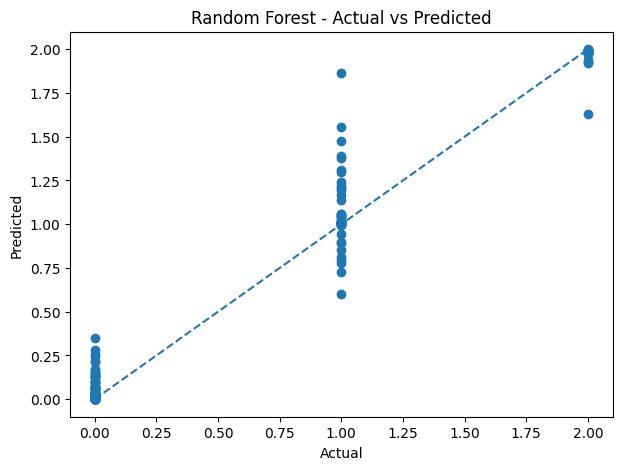

In [16]:
# Random Forest Regressor

rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_rf = rf_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Random Forest:")
print(model_rf.best_params_)
print("\n")

# Training Score

print("Training Score For Random Forest :",model_rf.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Random Forest :",model_rf.score(xtest, ytest) * 100)

# Predictions
ytest_pred = model_rf.predict(xtest)

# R2 Score
r2_rf = r2_score(ytest, ytest_pred)
print("R2 Score :", r2_rf)

# MAE
mae_rf = mean_absolute_error(ytest, ytest_pred)

print("MAE :", mae_rf)

# MSE
mse_rf = mean_squared_error(ytest, ytest_pred)

print("MSE :", mse_rf)

# RMSE
rmse_rf = np.sqrt(mse_rf)
print("RMSE :", rmse_rf)
print("\n")

# Actual vs Predicted

plt.figure(figsize=(7, 5))
plt.scatter(ytest, ytest_pred)
plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    '--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

## Extra Tree Regressor

Best Parameters For Extra Trees:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Training Score For Extra Trees : 100.0
Testing Score For Extra Trees : 89.86857423736893
R2 Score : 0.8986857423736893
MAE : 0.13435897435897434
MSE : 0.04471948717948718
RMSE : 0.21146982569503192




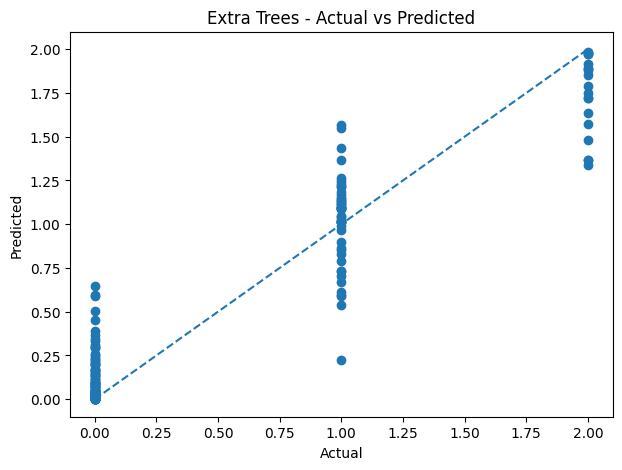

In [17]:
# Extra Trees Regressor

et = ExtraTreesRegressor(
    random_state=42
)

et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

et_grid = GridSearchCV(
    et,
    et_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_et = et_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Extra Trees:")
print(model_et.best_params_)
print("\n")

# Training Score

print("Training Score For Extra Trees :",model_et.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Extra Trees :",model_et.score(xtest, ytest) * 100)

# Predictions

ytest_pred = model_et.predict(xtest)

# R2 Score
r2_et = r2_score(ytest, ytest_pred)
print("R2 Score :", r2_et)

# MAE
mae_et = mean_absolute_error(ytest, ytest_pred)
print("MAE :", mae_et)

# MSE
mse_et = mean_squared_error(ytest, ytest_pred)
print("MSE :", mse_et)

# RMSE
rmse_et = np.sqrt(mse_et)
print("RMSE :", rmse_et)
print("\n")

# Actual vs Predicted Plot

plt.figure(figsize=(7, 5))

plt.scatter(ytest, ytest_pred)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    '--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Extra Trees - Actual vs Predicted")
plt.show()


## Performing Gradient Boosting 

Best Parameters For Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


Training Score For Gradient Boosting : 99.99996251321397
Testing Score For Gradient Boosting : 98.54743136901965
R2 Score : 0.9854743136901964
MAE : 0.012872387424225208
MSE : 0.006411548166304861
RMSE : 0.08007214351011756




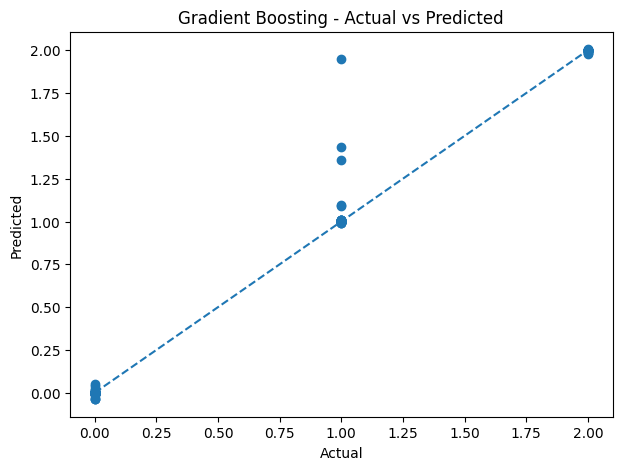

In [18]:
# Gradient Boosting Regressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    gb,
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_gb = gb_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Gradient Boosting:")
print(model_gb.best_params_)
print("\n")

# Training Score

print("Training Score For Gradient Boosting :",model_gb.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Gradient Boosting :",model_gb.score(xtest, ytest) * 100)

# Predictions
ytest_pred = model_gb.predict(xtest)

# R2 Score
r2_gb = r2_score(ytest, ytest_pred)
print("R2 Score :", r2_gb)

# MAE

mae_gb = mean_absolute_error(ytest, ytest_pred)

print("MAE :", mae_gb)

# MSE
mse_gb = mean_squared_error(ytest, ytest_pred)
print("MSE :", mse_gb)

# RMSE
rmse_gb = np.sqrt(mse_gb)
print("RMSE :", rmse_gb)
print("\n")

# Actual vs Predicted Plot

plt.figure(figsize=(7, 5))

plt.scatter(ytest, ytest_pred)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    '--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting - Actual vs Predicted")
plt.show()


## Performing XGBoost Regressor

Best Parameters For XGBoost:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


Training Score For XGBoost : 99.99533891677856
Testing Score For XGBoost : 95.35015225410461
R2 Score : 0.9535015225410461
MAE : 0.05270981043577194
MSE : 0.02052413672208786
RMSE : 0.14326247492657615




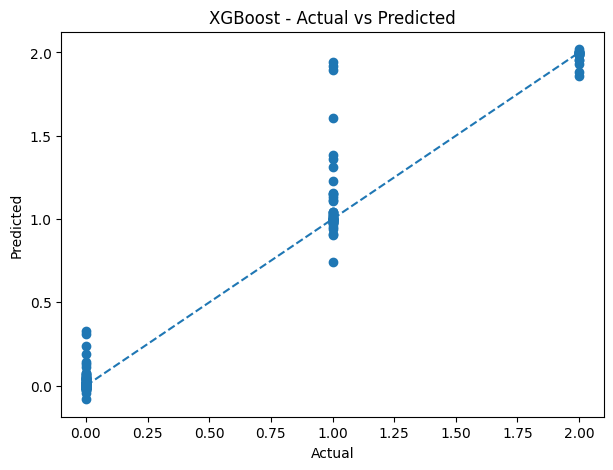

In [19]:
# XGBoost Regressor

xgb = XGBRegressor(
    random_state=42
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_xgb = xgb_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For XGBoost:")
print(model_xgb.best_params_)
print("\n")

# Training Score
print("Training Score For XGBoost :",model_xgb.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score For XGBoost :",model_xgb.score(xtest, ytest) * 100)

# Predictions
ytest_pred = model_xgb.predict(xtest)

# R2 Score
r2_xgb = r2_score(ytest, ytest_pred)
print("R2 Score :", r2_xgb)

# MAE
mae_xgb = mean_absolute_error(ytest, ytest_pred)
print("MAE :", mae_xgb)

# MSE
mse_xgb = mean_squared_error(ytest, ytest_pred)
print("MSE :", mse_xgb)

# RMSE
rmse_xgb = np.sqrt(mse_xgb)
print("RMSE :", rmse_xgb)
print("\n")

# Actual vs Predicted Plot

plt.figure(figsize=(7, 5))
plt.scatter(ytest, ytest_pred)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    '--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost - Actual vs Predicted")
plt.show()


## Performing CatBoost

Best Parameters For CatBoost:
{'depth': 6, 'iterations': 200, 'learning_rate': 0.1}


Training Score For CatBoost : 99.82139946728236
Testing Score For CatBoost : 97.73476065062891
R2 Score : 0.9773476065062892
MAE : 0.03679391345301867
MSE : 0.009998626493055678
RMSE : 0.09999313222944703




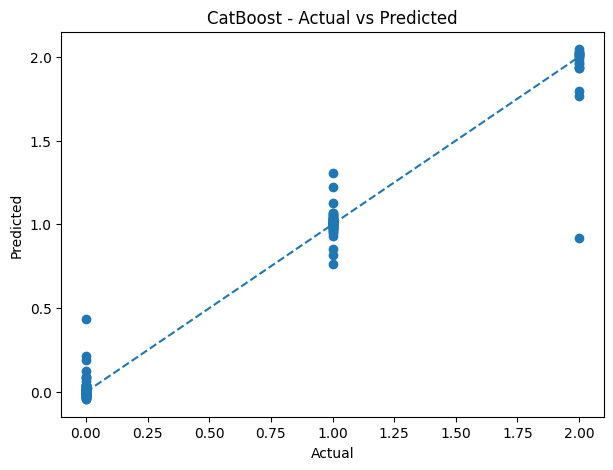

In [20]:
# CatBoost Regressor

cat = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cat_param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8]
}

cat_grid = GridSearchCV(
    cat,
    cat_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_cat = cat_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For CatBoost:")
print(model_cat.best_params_)
print("\n")

# Training Score
print("Training Score For CatBoost :",model_cat.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score For CatBoost :",model_cat.score(xtest, ytest) * 100)

# Predictions
ytest_pred = model_cat.predict(xtest)

# R2 Score
r2_cat = r2_score(ytest, ytest_pred)
print("R2 Score :", r2_cat)

# MAE
mae_cat = mean_absolute_error(ytest, ytest_pred)
print("MAE :", mae_cat)

# MSE
mse_cat = mean_squared_error(ytest, ytest_pred)
print("MSE :", mse_cat)

# RMSE
rmse_cat = np.sqrt(mse_cat)
print("RMSE :", rmse_cat)
print("\n")

# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(ytest, ytest_pred)
plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    '--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("CatBoost - Actual vs Predicted")
plt.show()